In [21]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# 1. LIST OF COMMUNITIES TO COMPARE
communities = ["Ixiamas", "Santos_Mercado"] # Tu peux en rajouter une 3ème ici !

# Dictionary to hold all the data
all_data = {}

print("--- DATA PROCESSING ---")
for comm in communities:
    folder = f"data ramp/{comm}/"
    print(f"Loading and processing {comm}...")
    
    # Load files
    fall = pd.read_csv(folder + "load_curve_community_fall_Norte_Amazonia.csv", sep=",")
    spring = pd.read_csv(folder + "load_curve_community_spring_Norte_Amazonia.csv", sep=",")
    summer = pd.read_csv(folder + "load_curve_community_summer_Norte_Amazonia.csv", sep=",")
    winter = pd.read_csv(folder + "load_curve_community_winter_Norte_Amazonia.csv", sep=",")
    year = pd.read_csv(filepath_or_buffer=folder + "load_curve_energy_service_full_year_Norte_Amazonia.csv", sep=",")
    
    # Calculate Total Load for the year before adding other columns
    year["total_load"] = year.drop(columns=["time"]).sum(axis=1)
    
    # Time in days and scale to kW for all seasons
    for df in [fall, spring, summer, winter, year]:
        df["day"] = df["time"] / 1440
    
    for df in [fall, spring, summer, winter]:
        df["community_k"] = df["community"] / 1000
        
    year["total_load_k"] = year["total_load"] / 1000
    
    # Save into our dictionary
    all_data[comm] = {
        "fall": fall, "spring": spring, "summer": summer,
        "winter": winter, "year": year
    }

print("✅ All data ready!\n")

--- DATA PROCESSING ---
Loading and processing Ixiamas...
Loading and processing Santos_Mercado...
✅ All data ready!



In [22]:
def format_yearly_xaxis(ax):
    # Set Month Ticks
    month_days = [0, 31, 62, 90, 121, 151, 182, 213, 244, 274, 305, 335]
    month_labels = ['Dec', 'Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov']
    ax.set_xticks(month_days)
    ax.set_xticklabels(month_labels)
    ax.set_xlim(0, 365)
    ax.set_xlabel("Month", fontsize=12)

    # Add Season Shading & Labels
    seasons = [
        ("Summer", 0, 90, 'red'),
        ("Fall", 90, 182, 'orange'),
        ("Winter", 182, 274, 'blue'),
        ("Spring", 274, 365, 'green')
    ]
    
    for name, start, end, color in seasons:
        ax.axvspan(start, end, color=color, alpha=0.08)
        # Place text at the top center of the shaded zone (y=0.98 in axis coordinates)
        ax.text((start + end) / 2, 0.98, name, transform=ax.get_xaxis_transform(), 
                ha='center', va='top', fontsize=11, color=color, weight='bold', alpha=0.6)

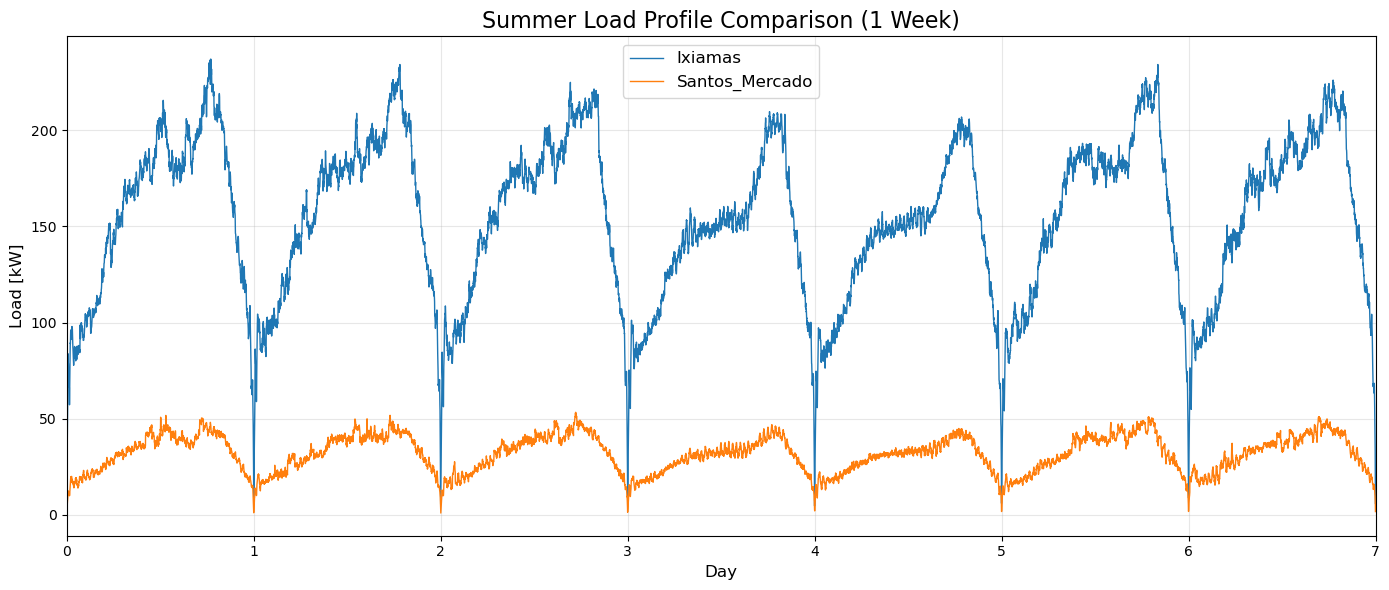

In [23]:
# ==========================================
# PLOT 1 : COMPARE SUMMER WEEK ACROSS CITIES
# ==========================================
n_days = 7
n_points = n_days * 1440

plt.figure(figsize=(14,6))

# Loop to plot the Summer line for each community
for comm in communities:
    df_summer = all_data[comm]["summer"]
    plt.plot(df_summer["day"][:n_points], df_summer["community_k"][:n_points], label=f"{comm}", linewidth=1.0)

plt.title("Summer Load Profile Comparison (1 Week)", fontsize=16)
plt.xlabel("Day", fontsize=12)
plt.ylabel("Load [kW]", fontsize=12)
plt.xlim(0, n_days)
plt.grid(True, alpha=0.3)
plt.legend(frameon=True, fontsize=12)
plt.tight_layout()
plt.show()

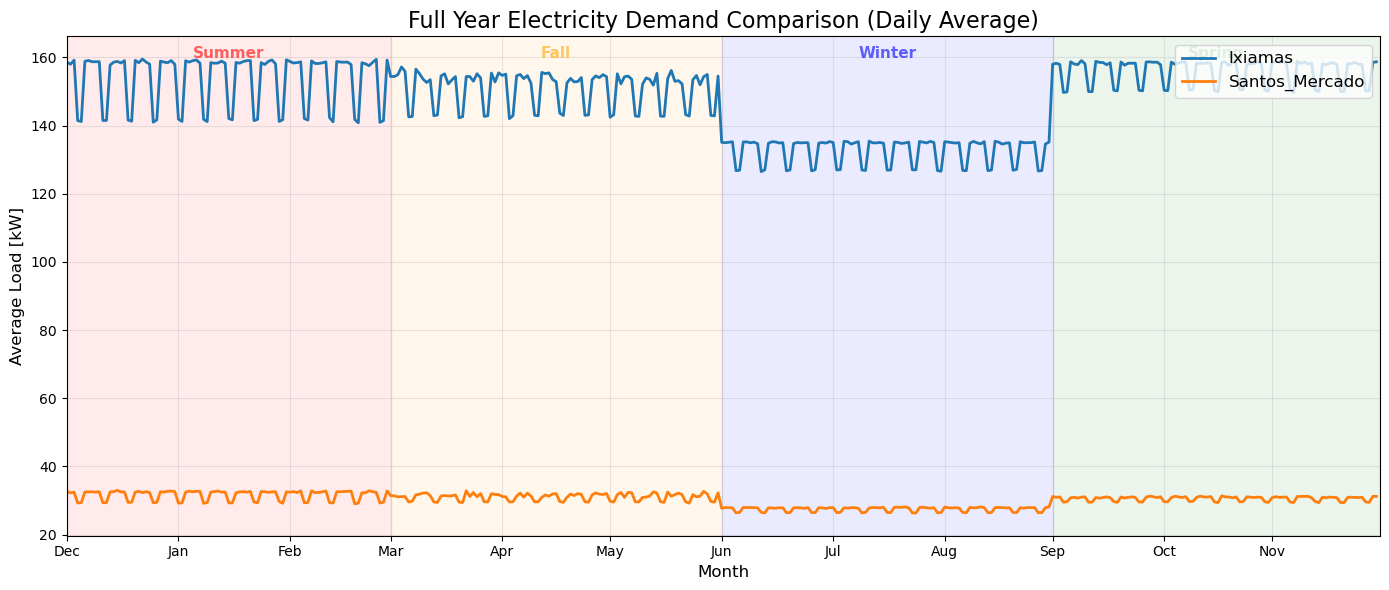

In [24]:
# ==========================================
# PLOT 2 : COMPARE FULL YEAR LOAD
# ==========================================
fig, ax = plt.subplots(figsize=(14,6))

for comm in communities:
    df_year = all_data[comm]["year"].copy()
    df_year["day_index"] = df_year["time"] // 1440
    daily_mean = df_year.groupby("day_index")["total_load_k"].mean()
    
    ax.plot(daily_mean.index, daily_mean.values, linewidth=2, label=f"{comm}")

ax.set_title("Full Year Electricity Demand Comparison (Daily Average)", fontsize=16)
ax.set_ylabel("Average Load [kW]", fontsize=12)
ax.grid(True, alpha=0.3)
ax.legend(frameon=True, fontsize=12, loc="upper right")

# Apply the formatting
format_yearly_xaxis(ax)

plt.tight_layout()
plt.show()

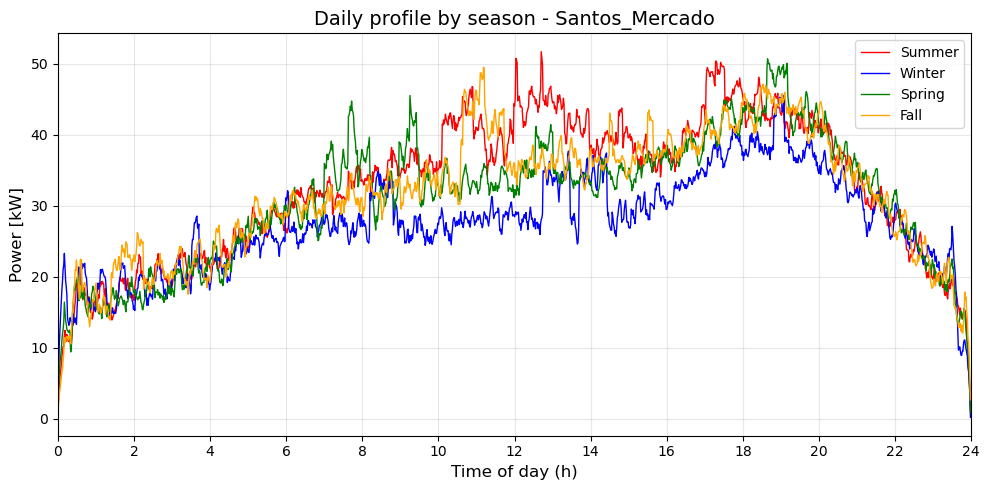

In [25]:
# ====================================
# PLOT 3 : IMPACT OF SEASONS OVER 24H 
# ====================================
city = "Santos_Mercado" # you can change with "Guayaramerín"
heures = pd.Series(range(1440)) / 60  # Axe X de 0h à 24h

plt.figure(figsize=(10,5))
plt.plot(heures, all_data[city]["summer"]["community_k"][:1440], label="Summer", color="red", linewidth=1.0)
plt.plot(heures, all_data[city]["winter"]["community_k"][:1440], label="Winter", color="blue", linewidth=1.0)
plt.plot(heures, all_data[city]["spring"]["community_k"][:1440], label="Spring", color="green", linewidth=1.0)
plt.plot(heures, all_data[city]["fall"]["community_k"][:1440], label="Fall", color="orange", linewidth=1.0)

plt.title(f"Daily profile by season - {city}", fontsize=14)
plt.xlabel("Time of day (h)", fontsize=12)
plt.ylabel("Power [kW]", fontsize=12)
plt.xticks(range(0, 25, 2)) 
plt.xlim(0, 24)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

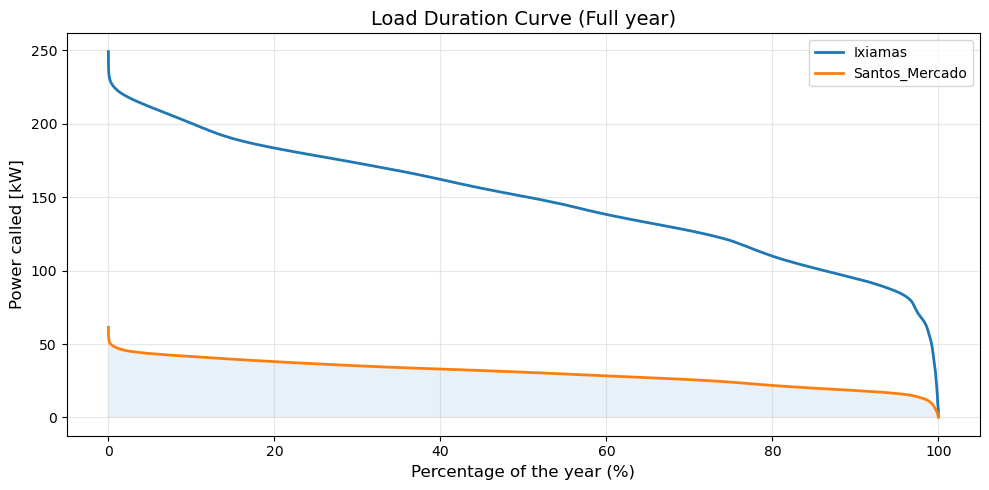

In [26]:
# =============================
# PLOT 4 : LOAD DURATION CURVE 
# =============================
plt.figure(figsize=(10,5))

for comm in communities:
    # We take the total annual load and sort it from largest to smallest.
    sorted_load = all_data[comm]["year"]["total_load_k"].sort_values(ascending=False).values
    
    # We create an X-axis representing percentages (from 0% of the time to 100% of the time)
    pourcentage_temps = (pd.Series(range(len(sorted_load))) / len(sorted_load)) * 100
    plt.plot(pourcentage_temps, sorted_load, label=comm, linewidth=2)

plt.title("Load Duration Curve (Full year)", fontsize=14)
plt.xlabel("Percentage of the year (%)", fontsize=12)
plt.ylabel("Power called [kW]", fontsize=12)
plt.grid(True, alpha=0.3)
plt.fill_between(pourcentage_temps, 0, sorted_load, alpha=0.1) # Add a nice colorful background
plt.legend()
plt.tight_layout()
plt.show()

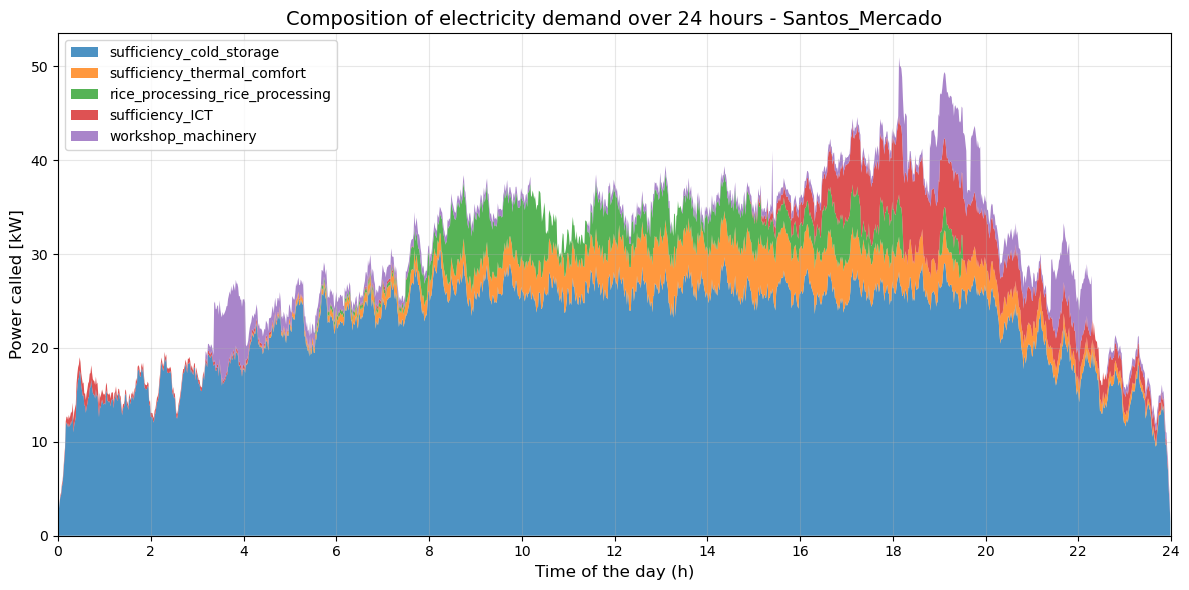

In [27]:
# ==========================================
# PLOT 5 : 24-HOUR USAGE DISTRIBUTION (Stacked Area)
# ========================================== 

df_day1 = all_data[city]["year"].iloc[:1440].copy()  # 1st day
colonnes_to_ignore = ["time", "day", "total_load", "total_load_k"]
df_usages = df_day1.drop(columns=colonnes_to_ignore)
top_5_usages = df_usages.sum().nlargest(5).index

# We convert these 5 uses into kW
donnees_empilees = [df_usages[usage]/1000 for usage in top_5_usages]

plt.figure(figsize=(12,6))
plt.stackplot(heures, donnees_empilees, labels=top_5_usages, alpha=0.8)

plt.title(f"Composition of electricity demand over 24 hours - {city}", fontsize=14)
plt.xlabel("Time of the day (h)", fontsize=12)
plt.ylabel("Power called [kW]", fontsize=12)
plt.xticks(range(0, 25, 2))
plt.xlim(0, 24)
plt.legend(loc='upper left', fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

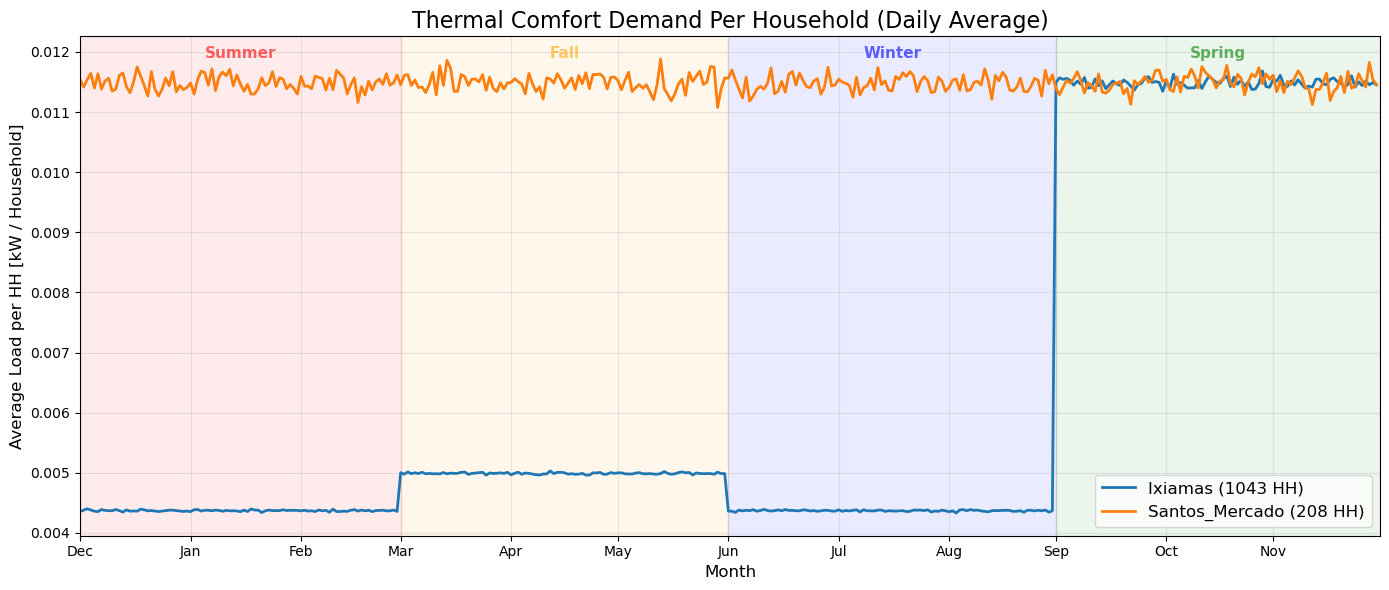

In [28]:
# ==========================================
# PLOT 6 : THERMAL COMFORT COMPARISON (Per Household)
# ==========================================

# Load exact household counts from the CSV
df_counts = pd.read_csv("../exctraction of data/output/municipalities_counts.csv", sep=",")
hh_counts = dict(zip(df_counts["municipality"], df_counts["non_elec_hh"]))

fig, ax = plt.subplots(figsize=(14,6))

for comm in communities:
    df_year = all_data[comm]["year"].copy()
    
    if "sufficiency_thermal_comfort" in df_year.columns:
        # Get the household count for this specific community (default to 1 if not found)
        hh_number = hh_counts.get(comm, 1)
        
        # 2. Convert to kW AND divide by dynamic number of households
        df_year["thermal_k_per_hh"] = (df_year["sufficiency_thermal_comfort"] / 1000) / hh_number
        df_year["day_index"] = df_year["time"] // 1440
        
        daily_thermal = df_year.groupby("day_index")["thermal_k_per_hh"].mean()
        ax.plot(daily_thermal.index, daily_thermal.values, linewidth=2, label=f"{comm} ({int(hh_number)} HH)")
    else:
        print(f"⚠️ No thermal comfort data for {comm}")

ax.set_title("Thermal Comfort Demand Per Household (Daily Average)", fontsize=16)
ax.set_ylabel("Average Load per HH [kW / Household]", fontsize=12)
ax.grid(True, alpha=0.3)
ax.legend(frameon=True, fontsize=12, loc="best")

# Apply the formatting from the helper function
format_yearly_xaxis(ax)

plt.tight_layout()
plt.show()


=== Santos_Mercado Metrics ===
New Peak Demand: 61.36 kW
Annual Rice Processing Energy: 3,842 kWh


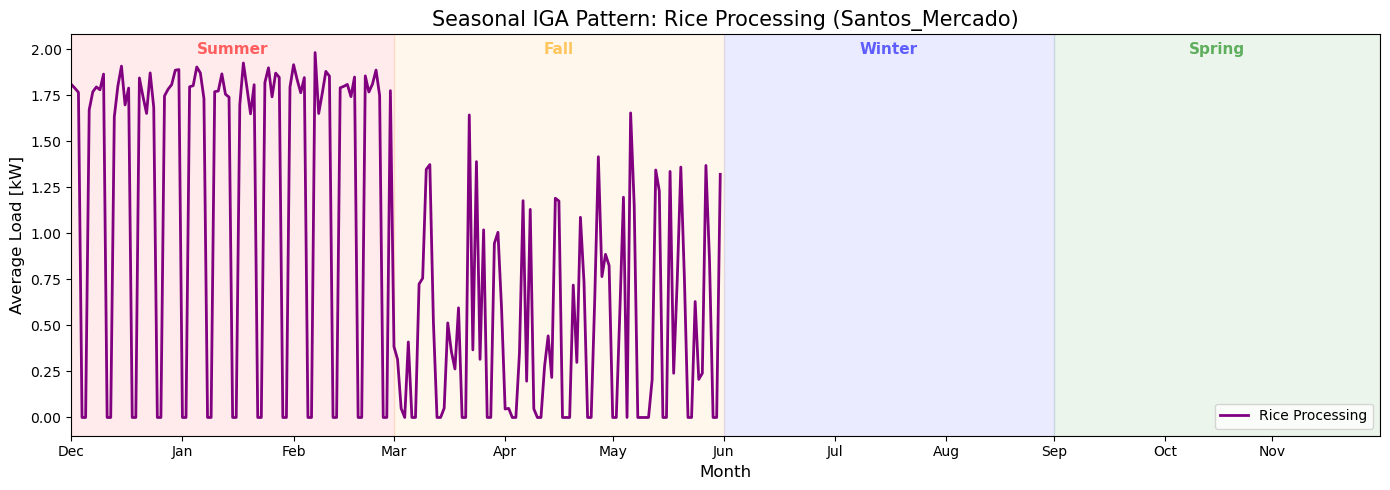

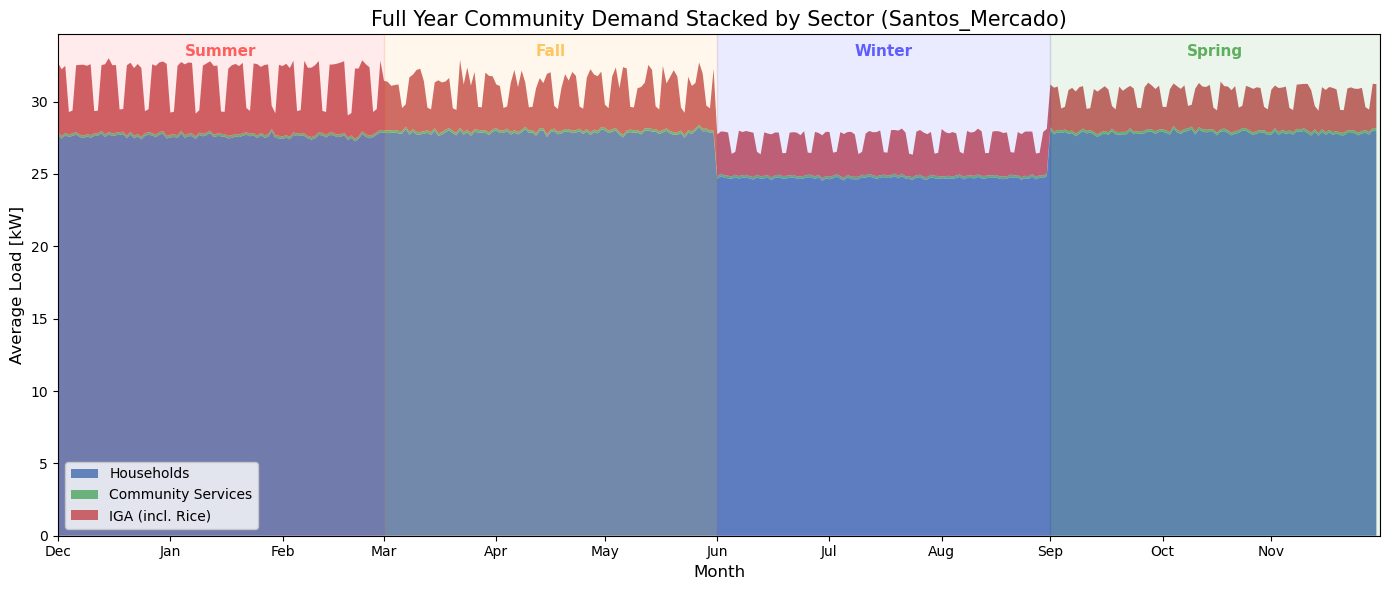

In [29]:
# ==========================================
# PLOT 7 & 8 : RICE PROCESSING
# ==========================================
city = "Santos_Mercado"
if city in all_data:
    df_year = all_data[city]["year"].copy()
    
    # Grouper par secteurs
    hh_cols = [c for c in df_year.columns if c.startswith("sufficiency_")]
    cs_cols = [c for c in df_year.columns if "school" in c or "health_center" in c or "public_lighting" in c]
    iga_cols = [c for c in df_year.columns if "store" in c or "restaurant" in c or "workshop" in c or "business" in c or "rice_processing" in c or "flour_processing" in c]
    
    df_year["total_hh_kW"] = df_year[hh_cols].sum(axis=1) / 1000
    df_year["total_cs_kW"] = df_year[cs_cols].sum(axis=1) / 1000
    df_year["total_iga_kW"] = df_year[iga_cols].sum(axis=1) / 1000
    df_year["total_community_kW"] = df_year["total_hh_kW"] + df_year["total_cs_kW"] + df_year["total_iga_kW"]
    
    # Isoler le rice processing
    rice_col = [c for c in df_year.columns if "rice_processing" in c]
    df_year["rice_kW"] = df_year[rice_col[0]] / 1000 if rice_col else 0
    
    # --- 1. METRICS (PRINT) ---
    print(f"\n=== {city} Metrics ===")
    print(f"New Peak Demand: {df_year['total_community_kW'].max():.2f} kW")
    print(f"Annual Rice Processing Energy: {df_year['rice_kW'].sum() / 60:,.0f} kWh")
    
    df_year["day_index"] = df_year["time"] // 1440
    
    # --- 2. PLOT: RICE PROCESSING DAILY PROFILE ---
    fig, ax = plt.subplots(figsize=(14,5))
    daily_rice = df_year.groupby("day_index")["rice_kW"].mean()
    ax.plot(daily_rice.index, daily_rice.values, linewidth=2, color="purple", label="Rice Processing")
    
    ax.set_title(f"Seasonal IGA Pattern: Rice Processing ({city})", fontsize=15)
    ax.set_ylabel("Average Load [kW]", fontsize=12)
    ax.legend(frameon=True, loc="best")
    format_yearly_xaxis(ax)
    plt.tight_layout()
    plt.show()
    
    # --- 3. PLOT: COMMUNITY LOAD STACKED BY SECTOR ---
    fig, ax = plt.subplots(figsize=(14,6))
    daily_hh = df_year.groupby("day_index")["total_hh_kW"].mean()
    daily_cs = df_year.groupby("day_index")["total_cs_kW"].mean()
    daily_iga = df_year.groupby("day_index")["total_iga_kW"].mean()
    
    ax.stackplot(daily_hh.index, daily_hh.values, daily_cs.values, daily_iga.values,
                 labels=["Households", "Community Services", "IGA (incl. Rice)"],
                 colors=["#4c72b0", "#55a868", "#c44e52"], alpha=0.85)
    
    ax.set_title(f"Full Year Community Demand Stacked by Sector ({city})", fontsize=15)
    ax.set_ylabel("Average Load [kW]", fontsize=12)
    ax.legend(loc="best", frameon=True)
    format_yearly_xaxis(ax)
    plt.tight_layout()
    plt.show()

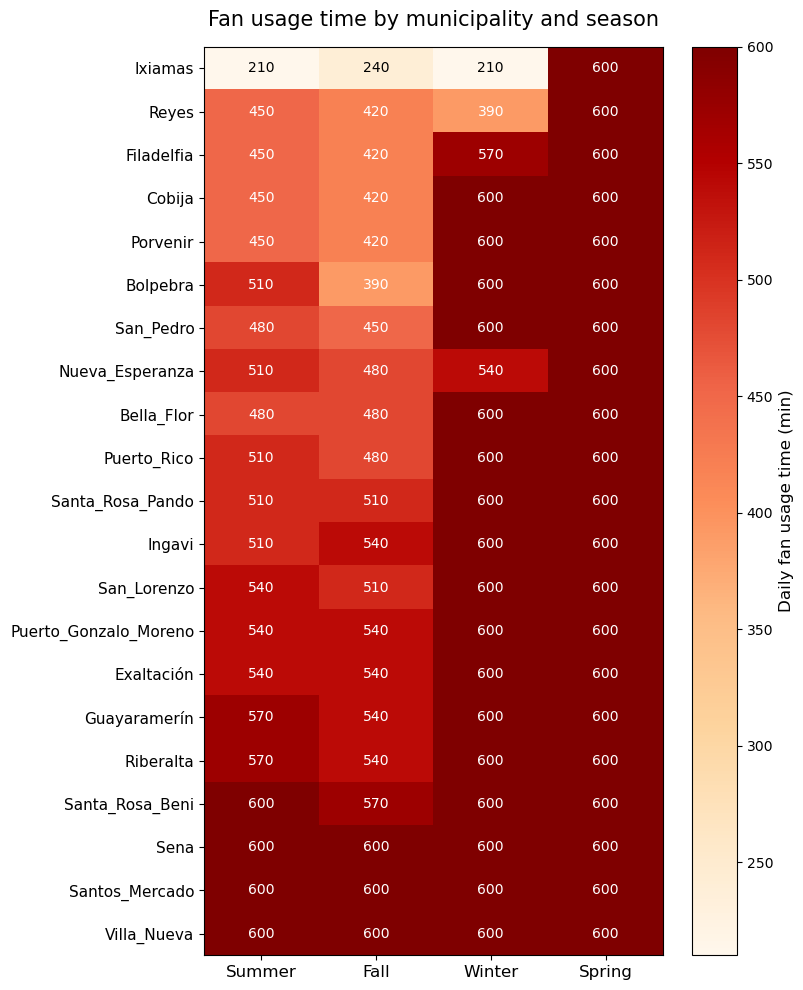

In [ ]:
# ==========================================
# PLOT 9 : FAN USAGE HEATMAP FROM CSV
# ==========================================
# 1. Load the CSV data
df_lookup = pd.read_csv("../renewable ninja/temperature/output/thermal_comfort_lookup.csv")

# 2. Pivot data: rows = municipality, cols = season, values = func_time
heatmap_df = df_lookup.pivot(index="municipality", columns="season", values="func_time")

# 3. Reorder columns (seasons)
seasons_order = ['summer', 'fall', 'winter', 'spring']
heatmap_df = heatmap_df[seasons_order]

# 4. Sort municipalities by annual average func_time (coldest at the top)
heatmap_df['annual_mean'] = heatmap_df.mean(axis=1)
heatmap_df = heatmap_df.sort_values("annual_mean", ascending=True)
heatmap_df = heatmap_df.drop(columns=['annual_mean'])

# 5. Plot the Heatmap
fig, ax = plt.subplots(figsize=(8, 10)) # Taller figure to fit all 21 names
cax = ax.imshow(heatmap_df.values, cmap="OrRd", aspect="auto") # Light orange/red scale

# Axes formatting
ax.set_xticks(range(len(seasons_order)))
ax.set_xticklabels([s.capitalize() for s in seasons_order], fontsize=12)
ax.set_yticks(range(len(heatmap_df.index)))
ax.set_yticklabels(heatmap_df.index, fontsize=11)
ax.set_title("Fan usage time by municipality and season", pad=15, fontsize=15)

# Colorbar
cbar = fig.colorbar(cax, ax=ax)
cbar.set_label("Daily fan usage time (min)", fontsize=12)

# Add text values inside each cell
heatmap_array = heatmap_df.values
max_val = np.nanmax(heatmap_array)

for i in range(heatmap_array.shape[0]):
    for j in range(heatmap_array.shape[1]):
        val = heatmap_array[i, j]
        # White text on dark cells, black on light cells
        text_color = "white" if val > (max_val * 0.6) else "black"
        ax.text(j, i, f"{val:.0f}", ha="center", va="center", color=text_color, fontsize=10)

plt.tight_layout()
plt.show()